# PROCESS Model 4: Simple Mediation

This notebook introduces **mediation analysis** (used for SPSS **PROCESS Model 4**).

Model 4 tests whether the effect of an independent variable **X** on an outcome **Y** is transmitted through a mediator **M**.

Conceptually:
- **a path**: $X \to M$
- **b path**: $M \to Y$ (controlling for $X$)
- **c' path**: direct effect $X \to Y$ (controlling for $M$)
- **c path**: total effect $X \to Y$ (without $M$)

Key equations:
$$
M = i_M + aX + e_M
$$
$$
Y = i_Y + c'X + bM + e_Y
$$

The **indirect effect** is $a \times b$.
The total effect is $c = c' + (a \times b)$.

In practice, PROCESS usually evaluates the indirect effect with **bootstrap confidence intervals**.
If the bootstrap CI for $a \times b$ does not include 0, the mediation effect is considered statistically supported.

## Error Terms and Probabilistic Model (Stan-ready)

### 1) What are $e_M$ and $e_Y$?

In the regression form
$$
M = i_M + aX + e_M
$$
$$
Y = i_Y + c'X + bM + e_Y
$$

$e_M$ and $e_Y$ are residual (unexplained) errors.
A common modeling choice is:
$$
e_M \sim \mathcal{N}(0, \sigma_M)
$$
$$
e_Y \sim \mathcal{N}(0, \sigma_Y)
$$

So, conditional on predictors,
$$
M \mid X \sim \mathcal{N}(i_M + aX, \sigma_M)
$$
$$
Y \mid X, M \sim \mathcal{N}(i_Y + c'X + bM, \sigma_Y)
$$

### 2) Probabilistic equations for Bayesian mediation

For observations $i = 1, \ldots, N$:
$$
M_i \sim \mathcal{N}(\mu_{Mi}, \sigma_M), \quad \mu_{Mi} = \alpha_M + aX_i
$$
$$
Y_i \sim \mathcal{N}(\mu_{Yi}, \sigma_Y), \quad \mu_{Yi} = \alpha_Y + c_{\text{prime}}X_i + bM_i
$$

Parameter priors (example weakly informative priors):
$$
\alpha_M \sim \mathcal{N}(0, 5), \quad \alpha_Y \sim \mathcal{N}(0, 5)
$$
$$
a \sim \mathcal{N}(0, 2), \quad b \sim \mathcal{N}(0, 2), \quad c_{\text{prime}} \sim \mathcal{N}(0, 2)
$$
$$
\sigma_M \sim \text{Exponential}(1), \quad \sigma_Y \sim \text{Exponential}(1)
$$

Derived quantities:
$$
\text{indirect} = a b, \quad \text{direct} = c_{\text{prime}}, \quad \text{total} = c_{\text{prime}} + ab
$$

This specification can be translated directly into Stan blocks:
- data: $N$, $X$, $M$, $Y$
- parameters: $\alpha_M$, $\alpha_Y$, $a$, $b$, $c_{\text{prime}}$, $\sigma_M$, $\sigma_Y$
- model: priors + two Normal likelihoods
- generated quantities: $\text{indirect}$, $\text{direct}$, $\text{total}$

## Mediation Equations with Covariates

Let the covariates be coded as follows:
- Gender: $g_i \in \{1,2\}$
- Country: $c_i \in \{1,2,3,4\}$

Using reference-category (dummy) coding:
- Gender reference: $g_i=1$ (one dummy: $G_{i2}=\mathbf{1}(g_i=2)$)
- Country reference: $c_i=1$ (dummies: $C_{i2}, C_{i3}, C_{i4}$)

Define the covariate vector
$$
\mathbf{z}_i = (G_{i2}, C_{i2}, C_{i3}, C_{i4})^\top.
$$

Then the mediation model becomes
$$
M_i \sim \mathcal{N}(\mu_{Mi}, \sigma_M), \quad \mu_{Mi} = \alpha_M + aX_i + \boldsymbol{\gamma}_M^\top \mathbf{z}_i
$$
$$
Y_i \sim \mathcal{N}(\mu_{Yi}, \sigma_Y), \quad \mu_{Yi} = \alpha_Y + c'X_i + bM_i + \boldsymbol{\gamma}_Y^\top \mathbf{z}_i
$$

Expanded covariate terms:
$$
\mu_{Mi} = \cdots + \gamma_{M,g}G_{i2} + \gamma_{M,2}C_{i2} + \gamma_{M,3}C_{i3} + \gamma_{M,4}C_{i4}
$$
$$
\mu_{Yi} = \cdots + \gamma_{Y,g}G_{i2} + \gamma_{Y,2}C_{i2} + \gamma_{Y,3}C_{i3} + \gamma_{Y,4}C_{i4}
$$

where $\boldsymbol{\gamma}_M$ and $\boldsymbol{\gamma}_Y$ are covariate coefficient vectors for the mediator and outcome equations, respectively.

The mediation effects are still
$$
\text{indirect} = ab, \quad \text{direct} = c', \quad \text{total} = c' + ab.
$$

Optional weakly informative priors for Stan:
$$
\alpha_M,\alpha_Y \sim \mathcal{N}(0,5), \; a,b,c' \sim \mathcal{N}(0,2),
$$
$$
\boldsymbol{\gamma}_M, \boldsymbol{\gamma}_Y \sim \mathcal{N}(\mathbf{0}, 2^2 \mathbf{I}), \; \sigma_M,\sigma_Y \sim \text{Exponential}(1).
$$

## Examples of $\mathbf{z}_i$ (Simplified)

Recall:
$$
\mathbf{z}_i = (G_{i2}, C_{i2}, C_{i3}, C_{i4})^\top
$$

### Example 1
If $(g_i, c_i) = (1,1)$ (all reference categories), then
$$
\mathbf{z}_i = (0,0,0,0)^\top.
$$

### Example 2
If $(g_i, c_i) = (2,3)$, then
- $G_{i2}=1$
- $C_{i2}=0,\; C_{i3}=1,\; C_{i4}=0$
so
$$
\mathbf{z}_i = (1,0,1,0)^\top.
$$

### Example 3
If $(g_i, c_i) = (2,4)$, then
$$
\mathbf{z}_i = (1,0,0,1)^\top.
$$

### Example 4
If $(g_i, c_i) = (1,2)$, then
$$
\mathbf{z}_i = (0,1,0,0)^\top.
$$

## Worked Example: Study Time -> Motivation -> Test Score (with Covariates)

Suppose we want to understand **how study time affects test scores** while controlling for student background.
A mediation story is:
- $X$: study time (hours per week)
- $M$: motivation (higher means more motivated)
- $Y$: test score
- Covariates: gender and country

Use dummy coding:
- $G_{i2}=\mathbf{1}(g_i=2)$ for gender ($g_i \in \{1,2\}$, reference $=1$)
- $C_{i2}, C_{i3}, C_{i4}$ for country ($c_i \in \{1,2,3,4\}$, reference $=1$)
- $\mathbf{z}_i = (G_{i2}, C_{i2}, C_{i3}, C_{i4})^\top$

A covariate-adjusted data-generating model is:
$$
M_i = \alpha_M + aX_i + \boldsymbol{\gamma}_M^\top \mathbf{z}_i + e_{Mi}, \quad e_{Mi} \sim \mathcal{N}(0,\sigma_M)
$$
$$
Y_i = \alpha_Y + c'X_i + bM_i + \boldsymbol{\gamma}_Y^\top \mathbf{z}_i + e_{Yi}, \quad e_{Yi} \sim \mathcal{N}(0,\sigma_Y)
$$

Interpretation:
- indirect effect = $ab$
- direct effect = $c'$
- total effect = $c' + ab$

The next code cell simulates this process for $N$ students, including gender and country.

In [1]:
import numpy as np
import pandas as pd

# Reproducible simulation
rng = np.random.default_rng(5101)

# Number of students
N = 100

# X: study time (hours/week) from a Poisson distribution
study_time = rng.poisson(lam=10, size=N).astype(float)

# Covariates
gender = rng.integers(1, 3, size=N)      # 1 or 2
country = rng.integers(1, 5, size=N)     # 1, 2, 3, or 4

# Dummy coding (reference: gender=1, country=1)
G2 = (gender == 2).astype(int)
C2 = (country == 2).astype(int)
C3 = (country == 3).astype(int)
C4 = (country == 4).astype(int)

# True parameters for mediation model
alpha_M = 2.0
a = 0.45
sigma_M = 1.0

alpha_Y = 40.0
c_prime = 1.5
b = 3.0
sigma_Y = 5.0

# Covariate effects in mediator equation
gamma_M_g2 = 0.30
gamma_M_c2 = -0.20
gamma_M_c3 = 0.15
gamma_M_c4 = 0.40

# Covariate effects in outcome equation
gamma_Y_g2 = 1.20
gamma_Y_c2 = -1.50
gamma_Y_c3 = 0.80
gamma_Y_c4 = 2.00

# Generate mediator M: motivation
mu_M = (
    alpha_M
    + a * study_time
    + gamma_M_g2 * G2
    + gamma_M_c2 * C2
    + gamma_M_c3 * C3
    + gamma_M_c4 * C4
)
motivation = mu_M + rng.normal(0, sigma_M, size=N)

# Generate outcome Y: test score
mu_Y = (
    alpha_Y
    + c_prime * study_time
    + b * motivation
    + gamma_Y_g2 * G2
    + gamma_Y_c2 * C2
    + gamma_Y_c3 * C3
    + gamma_Y_c4 * C4
)
test_score = mu_Y + rng.normal(0, sigma_Y, size=N)

# Keep scores in a plausible range
test_score = np.clip(test_score, 0, 100)

df = pd.DataFrame(
    {
        "student_id": np.arange(1, N + 1),
        "study_time": study_time,
        "gender": gender,
        "country": country,
        "G2": G2,
        "C2": C2,
        "C3": C3,
        "C4": C4,
        "motivation": motivation,
        "test_score": test_score,
    }
)

print(df.head())
print()
print("Approximate true mediation effects used in simulation:")
print(f"indirect (a*b) = {a*b:.3f}")
print(f"direct (c') = {c_prime:.3f}")
print(f"total = {c_prime + a*b:.3f}")

   student_id  study_time  gender  country  G2  C2  C3  C4  motivation  \
0           1        10.0       2        1   1   0   0   0    8.652815   
1           2        10.0       2        1   1   0   0   0    8.083893   
2           3        18.0       1        4   0   0   0   1    9.368327   
3           4         8.0       1        1   0   0   0   0    6.407719   
4           5        11.0       2        2   1   1   0   0    7.181948   

   test_score  
0   73.212934  
1   86.544306  
2  100.000000  
3   65.999036  
4   92.136032  

Approximate true mediation effects used in simulation:
indirect (a*b) = 1.350
direct (c') = 1.500
total = 2.850


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

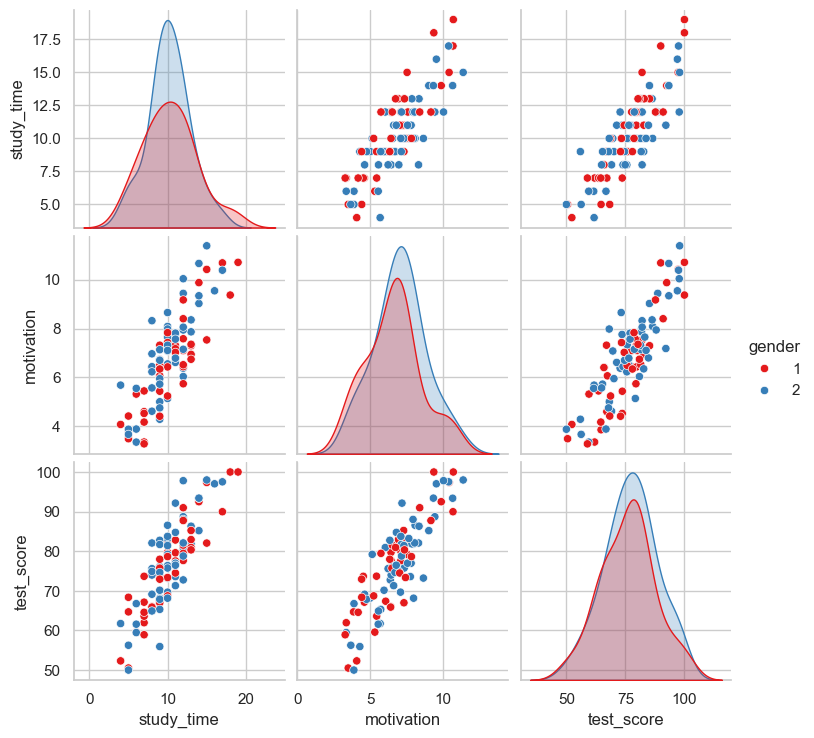

In [3]:
sns.pairplot(df, vars=["study_time", "motivation", "test_score"], hue="gender", palette="Set1")

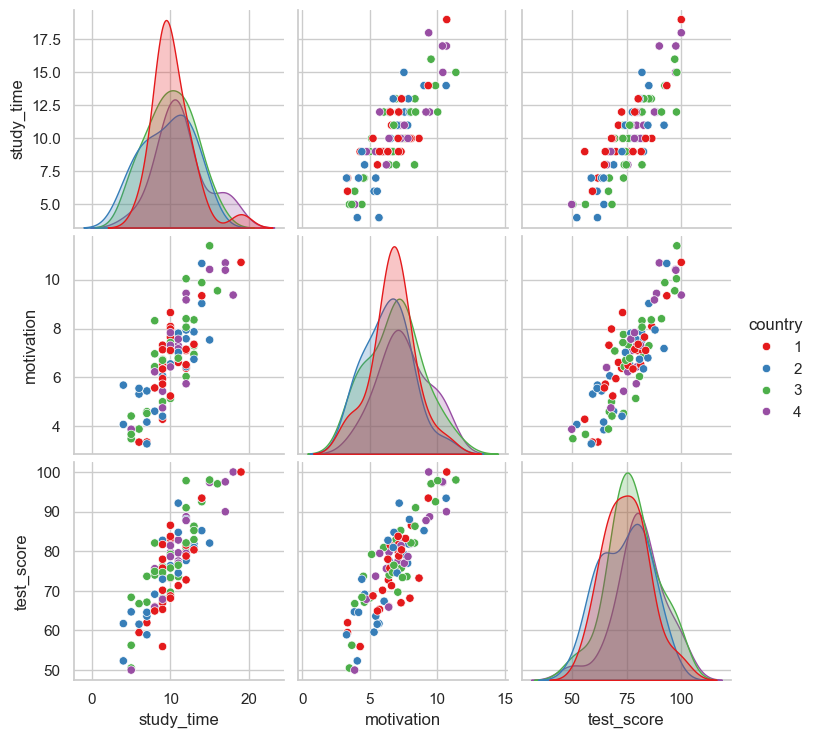

In [4]:
sns.pairplot(df, vars=["study_time", "motivation", "test_score"], hue="country", palette="Set1")

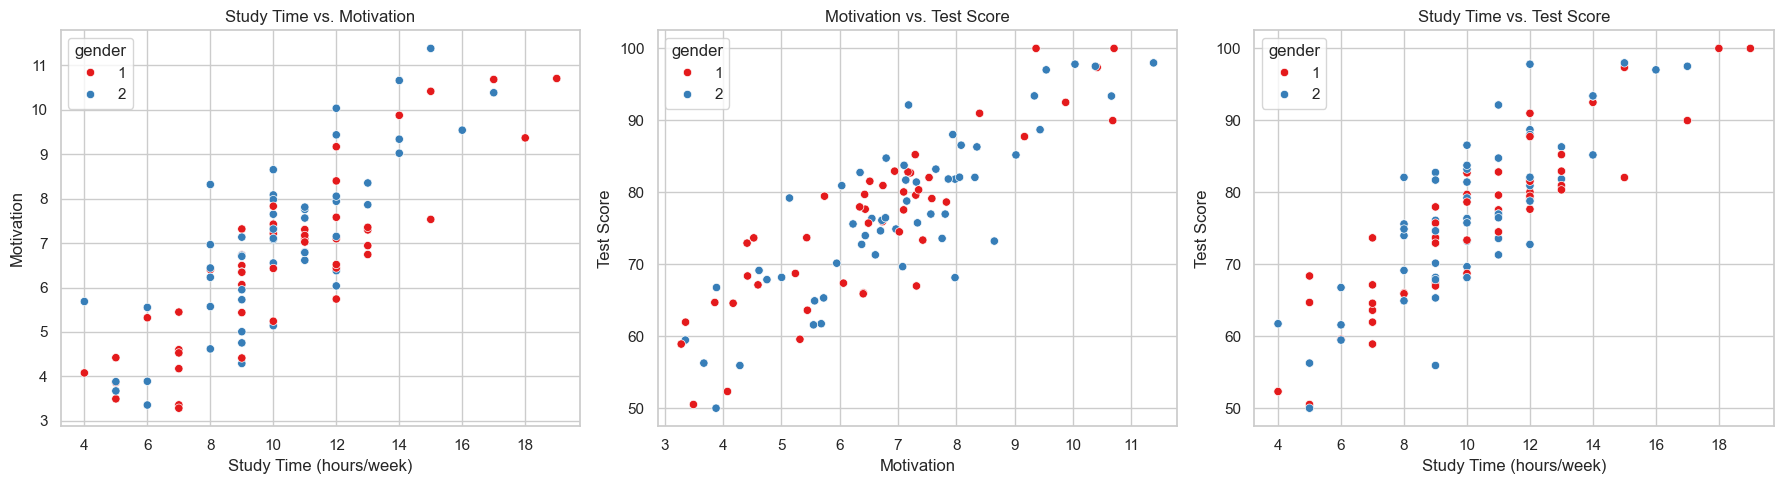

In [5]:
# Detailed scatter plots

# Set style
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Study time vs. Motivation
sns.scatterplot(x="study_time", y="motivation", hue="gender", data=df, ax=axes[0], palette="Set1")
axes[0].set_title("Study Time vs. Motivation")
axes[0].set_xlabel("Study Time (hours/week)")
axes[0].set_ylabel("Motivation")

# 2. Motivation vs. Test Score
sns.scatterplot(x="motivation", y="test_score", hue="gender", data=df, ax=axes[1], palette="Set1")
axes[1].set_title("Motivation vs. Test Score")
axes[1].set_xlabel("Motivation")
axes[1].set_ylabel("Test Score")

# 3. Study time vs. Test Score
sns.scatterplot(x="study_time", y="test_score", hue="gender", data=df, ax=axes[2], palette="Set1")
axes[2].set_title("Study Time vs. Test Score")
axes[2].set_xlabel("Study Time (hours/week)")
axes[2].set_ylabel("Test Score")

plt.tight_layout()
plt.show()

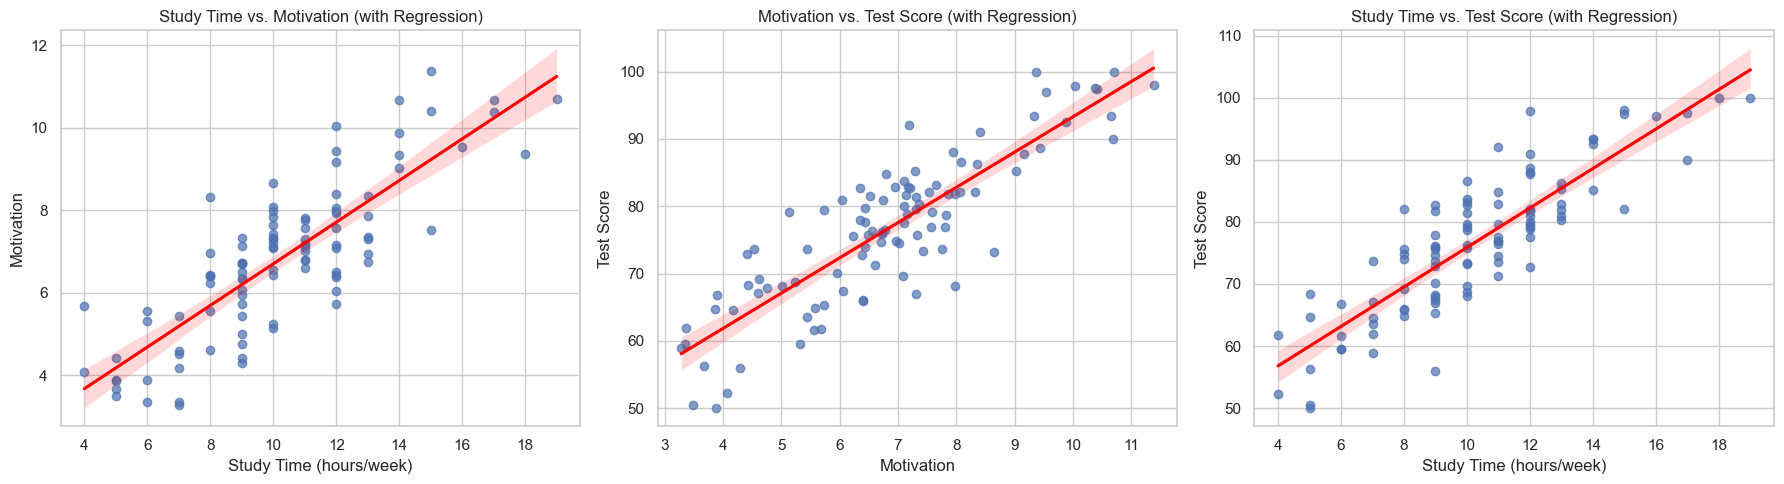

In [6]:
# Scatter plots with regression lines (with confidence intervals)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Study time vs. Motivation with regression line
sns.regplot(x="study_time", y="motivation", data=df, ax=axes[0], scatter_kws={'alpha':0.7}, line_kws={'color':'red'}, ci=95)
axes[0].set_title("Study Time vs. Motivation (with Regression)")
axes[0].set_xlabel("Study Time (hours/week)")
axes[0].set_ylabel("Motivation")

# 2. Motivation vs. Test Score with regression line
sns.regplot(x="motivation", y="test_score", data=df, ax=axes[1], scatter_kws={'alpha':0.7}, line_kws={'color':'red'}, ci=95)
axes[1].set_title("Motivation vs. Test Score (with Regression)")
axes[1].set_xlabel("Motivation")
axes[1].set_ylabel("Test Score")

# 3. Study time vs. Test Score with regression line
sns.regplot(x="study_time", y="test_score", data=df, ax=axes[2], scatter_kws={'alpha':0.7}, line_kws={'color':'red'}, ci=95)
axes[2].set_title("Study Time vs. Test Score (with Regression)")
axes[2].set_xlabel("Study Time (hours/week)")
axes[2].set_ylabel("Test Score")

plt.tight_layout()
plt.show()

In [7]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

# PROCESS Model 4: X -> M -> Y, controlling for gender and country dummies
# 1. M ~ X + covariates
model_M = smf.ols('motivation ~ study_time + G2 + C2 + C3 + C4', data=df).fit()
a = model_M.params['study_time']

# 2. Y ~ X + M + covariates
model_Y = smf.ols('test_score ~ study_time + motivation + G2 + C2 + C3 + C4', data=df).fit()
b = model_Y.params['motivation']
c_prime = model_Y.params['study_time']

# 3. Indirect, direct, total effects
indirect = a * b
direct = c_prime
total = direct + indirect

# 4. Bootstrap CI for indirect effect
n_boot = 1000
boot_indirect = []
rng = np.random.default_rng(5101)
for _ in range(n_boot):
    sample = df.sample(n=len(df), replace=True, random_state=rng.integers(1e9))
    m1 = smf.ols('motivation ~ study_time + G2 + C2 + C3 + C4', data=sample).fit()
    m2 = smf.ols('test_score ~ study_time + motivation + G2 + C2 + C3 + C4', data=sample).fit()
    boot_indirect.append(m1.params['study_time'] * m2.params['motivation'])
boot_indirect = np.array(boot_indirect)
ci_low, ci_high = np.percentile(boot_indirect, [2.5, 97.5])

print("PROCESS Model 4 (Simple Mediation) Results:\n")
print(f"a (X -> M): {a:.3f}")
print(f"b (M -> Y | X): {b:.3f}")
print(f"c' (X -> Y | M): {c_prime:.3f}")
print(f"Indirect effect (a*b): {indirect:.3f}")
print(f"Direct effect (c'): {direct:.3f}")
print(f"Total effect: {total:.3f}")
print(f"Bootstrap 95% CI for indirect effect: [{ci_low:.3f}, {ci_high:.3f}]")

# Statistical remarks
print("\nStatistical Analysis Remarks:")
if ci_low > 0 or ci_high < 0:
    print("The 95% bootstrap CI for the indirect effect does NOT include 0. Mediation is statistically supported.")
else:
    print("The 95% bootstrap CI for the indirect effect includes 0. Mediation is NOT statistically supported.")

PROCESS Model 4 (Simple Mediation) Results:

a (X -> M): 0.498
b (M -> Y | X): 2.840
c' (X -> Y | M): 1.753
Indirect effect (a*b): 1.415
Direct effect (c'): 1.753
Total effect: 3.168
Bootstrap 95% CI for indirect effect: [0.913, 1.969]

Statistical Analysis Remarks:
The 95% bootstrap CI for the indirect effect does NOT include 0. Mediation is statistically supported.


In [8]:
# Statistical interpretation of covariate coefficients
print("\nCovariate Coefficient Interpretation:")
covariates = ['G2', 'C2', 'C3', 'C4']
for cov in covariates:
    coef_M = model_M.params.get(cov, np.nan)
    pval_M = model_M.pvalues.get(cov, np.nan)
    coef_Y = model_Y.params.get(cov, np.nan)
    pval_Y = model_Y.pvalues.get(cov, np.nan)
    print(f"{cov}: Motivation model coef = {coef_M:.3f} (p = {pval_M:.3g}), Test score model coef = {coef_Y:.3f} (p = {pval_Y:.3g})")
    if pval_M < 0.05:
        print(f"  - {cov} has a statistically significant effect on motivation.")
    else:
        print(f"  - {cov} does not have a statistically significant effect on motivation.")
    if pval_Y < 0.05:
        print(f"  - {cov} has a statistically significant effect on test score.")
    else:
        print(f"  - {cov} does not have a statistically significant effect on test score.")


Covariate Coefficient Interpretation:
G2: Motivation model coef = 0.523 (p = 0.0146), Test score model coef = 0.135 (p = 0.898)
  - G2 has a statistically significant effect on motivation.
  - G2 does not have a statistically significant effect on test score.
C2: Motivation model coef = -0.029 (p = 0.92), Test score model coef = 1.561 (p = 0.265)
  - C2 does not have a statistically significant effect on motivation.
  - C2 does not have a statistically significant effect on test score.
C3: Motivation model coef = 0.213 (p = 0.448), Test score model coef = 2.859 (p = 0.0378)
  - C3 does not have a statistically significant effect on motivation.
  - C3 has a statistically significant effect on test score.
C4: Motivation model coef = 0.355 (p = 0.248), Test score model coef = 1.774 (p = 0.236)
  - C4 does not have a statistically significant effect on motivation.
  - C4 does not have a statistically significant effect on test score.


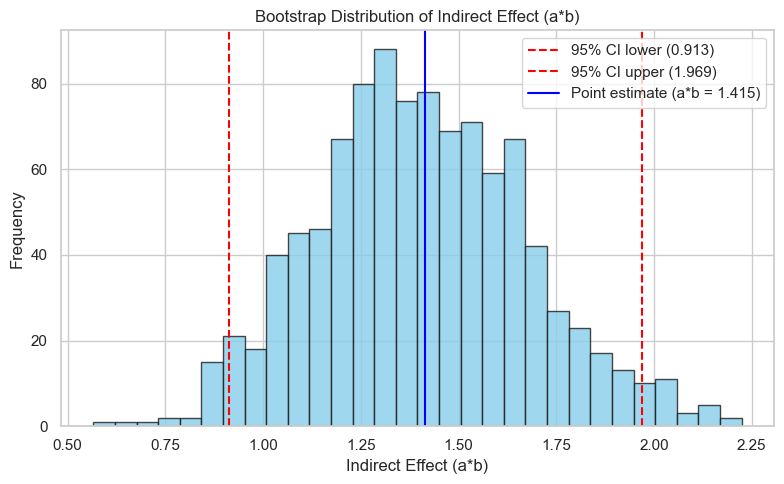

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(boot_indirect, bins=30, color='skyblue', edgecolor='k', alpha=0.8)
plt.axvline(ci_low, color='red', linestyle='--', label=f'95% CI lower ({ci_low:.3f})')
plt.axvline(ci_high, color='red', linestyle='--', label=f'95% CI upper ({ci_high:.3f})')
plt.axvline(indirect, color='blue', linestyle='-', label=f'Point estimate (a*b = {indirect:.3f})')
plt.title('Bootstrap Distribution of Indirect Effect (a*b)')
plt.xlabel('Indirect Effect (a*b)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

---

## Bayesian Inference

## Stan Code for PROCESS Model 4 with Covariates

Below is Stan code for the mediation model with covariates (gender and country dummies):

- This code uses a normal model for the mediator and the test score. (Later beta-binomial model will be introduced for integer scores)
- Covariates are included as dummy variables in both equations.
- The indirect, direct, and total effects are computed in the generated quantities block.

In [10]:
stan_code = """
data {
  int<lower=1> N;
  vector[N] Y; // test score (continuous normal approximation, 0-100)
  vector[N] X; // study time
  vector[N] M; // motivation
  array[N] int<lower=0,upper=1> G2;
  array[N] int<lower=0,upper=1> C2;
  array[N] int<lower=0,upper=1> C3;
  array[N] int<lower=0,upper=1> C4;
}
parameters {
  real alpha_M;
  real a;
  vector[4] gamma_M;
  real<lower=0> sigma_M;

  real alpha_Y;
  real c_prime;
  real b;
  vector[4] gamma_Y;
  real<lower=0> sigma_Y;
}
transformed parameters {
  vector[N] mu_M;
  vector[N] mu_Y;
  for (i in 1:N) {
    mu_M[i] = alpha_M + a * X[i] + gamma_M[1]*G2[i] + gamma_M[2]*C2[i] + gamma_M[3]*C3[i] + gamma_M[4]*C4[i];
    mu_Y[i] = alpha_Y + c_prime * X[i] + b * M[i] + gamma_Y[1]*G2[i] + gamma_Y[2]*C2[i] + gamma_Y[3]*C3[i] + gamma_Y[4]*C4[i];
  }
}
model {
  // Priors
  alpha_M ~ normal(0, 5);
  a ~ normal(0, 2);
  gamma_M ~ normal(0, 2);
  sigma_M ~ exponential(1);

  alpha_Y ~ normal(0, 5);
  c_prime ~ normal(0, 2);
  b ~ normal(0, 2);
  gamma_Y ~ normal(0, 2);
  sigma_Y ~ exponential(1);

  // Mediator model
  M ~ normal(mu_M, sigma_M);

  // Outcome model (normal approximation for Y)
  Y ~ normal(mu_Y, sigma_Y);
}
generated quantities {
  real indirect = a * b;
  real direct = c_prime;
  real total = c_prime + a * b;
}
"""

In [11]:
from cmdstanpy import cmdstan_path
print(cmdstan_path())

C:\Users\yongd\.cmdstan\cmdstan-2.37.0


In [12]:
# Bayesian inference using cmdstanpy for PROCESS Model 4 (Normal outcome)
from cmdstanpy import CmdStanModel
import numpy as np
import pandas as pd
import os
import tempfile
import pathlib

stan_file = pathlib.Path("process_model4.stan")
stan_file.write_text(stan_code)

# Prepare data for Stan (Y as float: normal approximation)
stan_data = {
    "N": N,
    "Y": test_score,          # pass as float for vector[N] Y in Stan
    "X": study_time,
    "M": motivation,
    "G2": G2,
    "C2": C2,
    "C3": C3,
    "C4": C4,
}

# Compile Stan model
model = CmdStanModel(stan_file=str(stan_file))

# Sample from posterior
fit = model.sample(data=stan_data,
                   seed=5101,
                   chains=4,
                   parallel_chains=4,
                   iter_warmup=1000,
                   iter_sampling=1000,
                   show_progress=True)

# Extract posterior samples
posterior = fit.draws_pd()

# Print summary of key parameters
print(fit.summary().loc[["a", "b", "c_prime", "indirect", "direct", "total"]])

22:34:00 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS-5101\misc\process_model4.stan to exe file C:\Users\yongd\Downloads\KOS-5101\misc\process_model4.exe


22:34:12 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS-5101\misc\process_model4.exe


22:34:13 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

22:34:15 - cmdstanpy - INFO - CmdStan done processing.


              Mean      MCSE    StdDev       MAD        5%       50%  \
a         0.498577  0.000710  0.035128  0.034793  0.441081  0.497979   
b         3.201960  0.009581  0.478237  0.483972  2.423430  3.194880   
c_prime   1.949650  0.005682  0.285190  0.281751  1.484340  1.946750   
indirect  1.596770  0.005319  0.266620  0.261756  1.176440  1.589710   
direct    1.949650  0.005682  0.285190  0.281751  1.484340  1.946750   
total     3.546420  0.003614  0.201484  0.199939  3.217160  3.544710   

               95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
a         0.556665   2457.42   2774.37     679.783  1.00070  
b         3.993060   2505.16   2515.89     692.989  1.00302  
c_prime   2.416120   2562.22   2151.26     708.773  1.00026  
indirect  2.050510   2525.10   2628.81     698.505  1.00185  
direct    2.416120   2562.22   2151.26     708.773  1.00026  
total     3.878000   3145.69   2874.32     870.177  1.00011  


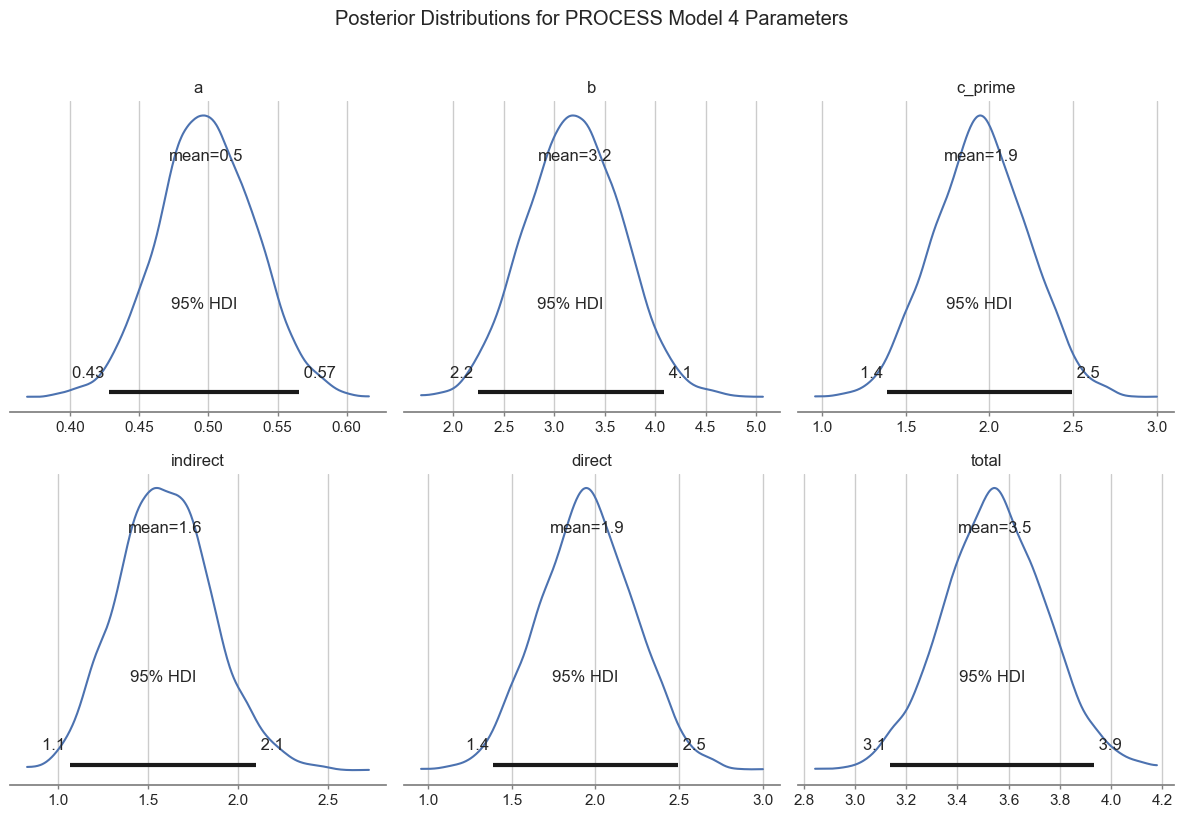

In [13]:
# Visualize MCMC-based Bayesian inference results
import matplotlib.pyplot as plt
import arviz as az

# If not already present, convert posterior to InferenceData for arviz
idata = az.from_cmdstanpy(posterior=fit)

# Plot posterior distributions for key parameters
az.plot_posterior(idata, var_names=["a", "b", "c_prime", "indirect", "direct", "total"],
                 hdi_prob=0.95,
                 figsize=(12, 8))
plt.suptitle("Posterior Distributions for PROCESS Model 4 Parameters", y=1.02)
plt.tight_layout()
plt.show()

## Answers to the Research Questions (Based on MCMC Posterior)

All estimates below are **posterior means** with **95% highest-density intervals (HDI)** from 4,000 MCMC draws (4 chains × 1,000 samples). $\hat{R} \approx 1.00$ for all parameters, indicating good chain convergence.

---

### RQ1. Does study time increase motivation? (*a* path)

**Yes.** Each additional hour of study time per week raises motivation by **0.50 units** on average (95% HDI: [0.44, 0.56]).  
The interval excludes 0, so the *a* path is credibly positive.

---

### RQ2. Does motivation predict test scores, controlling for study time? (*b* path)

**Yes.** Each one-unit increase in motivation is associated with **3.20 points** higher test score (95% HDI: [2.42, 3.99]).  
The interval excludes 0, so the *b* path is credibly positive.

---

### RQ3. Is there a direct effect of study time on test scores, independent of motivation? (*c′* path)

**Yes.** Even after accounting for the mediating role of motivation, each additional hour of study time raises the test score by **1.95 points** on average (95% HDI: [1.48, 2.42]).  
This suggests **partial mediation**: study time benefits test scores both *through* motivation and through other pathways not captured here.

---

### RQ4. How large is the indirect (mediated) effect? (*a × b*)

The indirect effect is **1.60 points per hour of study time** (95% HDI: [1.18, 2.05]).  
Because the entire HDI lies above 0, motivation is a credible mediator of the study time → test score relationship.

---

### RQ5. What is the total effect of study time on test scores?

The total effect (direct + indirect) is **3.55 points per hour** (95% HDI: [3.22, 3.88]).

| Effect | Posterior Mean | 95% HDI | % of Total |
|--------|---------------|---------|-----------|
| Indirect (*a × b*) | 1.60 | [1.18, 2.05] | ~45% |
| Direct (*c′*) | 1.95 | [1.48, 2.42] | ~55% |
| **Total** | **3.55** | **[3.22, 3.88]** | 100% |

Roughly **45% of the total effect** of study time on test scores is transmitted through motivation, and **55% operates via other direct pathways**.

---

### Summary

> Study time significantly improves test scores both **directly** and **indirectly through motivation**. The mediation is **partial**: motivation accounts for about 45% of the total effect, while the remaining 55% reflects direct benefits (e.g., knowledge accumulation, practice effects) not mediated by motivation. These conclusions hold after controlling for gender and country.

---

## Discussion: Covariates, Model Assumptions, and the Direct Effect

---

### 1. "배경 변수를 통제한다"는 게 무슨 뜻인가?

#### 핵심 문제: 혼재 변수(confound)

성별이나 국가를 **무시하고** 분석하면 어떤 문제가 생길까요?

예를 들어 현실에서 이런 상황을 생각해 보세요:

```
여학생(gender=2)이 남학생보다:
  - 공부 시간이 더 많고  (X↑)
  - 동기부여도 더 높고   (M↑)
  - 시험 점수도 더 높다  (Y↑)
```

이 경우 **성별**이 X, M, Y 세 변수 모두에 영향을 미칩니다:

```
         gender
        /   |   \
       ↓    ↓    ↓
       X → M → Y
```

만약 성별을 통제하지 않으면, "공부 시간이 동기부여를 높인다"는 *a* 경로가 실제보다 **과장**될 수 있어요.
왜냐하면 그 관계 일부가 사실은 **"여학생이기 때문에 공부도 많이 하고 동기도 높다"** 는 성별 효과일 수 있기 때문입니다.

"통제한다"는 것은 **같은 성별, 같은 국가 학생들끼리만 비교**해서 *a*, *b*, *c′* 를 추정한다는 의미입니다.
즉, *a* 계수는 이렇게 해석됩니다:

> "성별과 국가가 **동일한** 두 학생이 있을 때, 공부 시간이 1시간 더 많은 학생이 동기부여가 얼마나 더 높은가?"

성별·국가 차이를 먼저 "제거"한 뒤 남은 순수한 공부 시간의 효과만 보는 것입니다.

---

### 2. 왜 공변량은 절편(intercept)에만 연결되는가? — 기울기 동질성 가정

모형을 다시 보면:

$$\mu_{Mi} = \alpha_M + a X_i + \gamma_{M,g} G_{i2} + \gamma_{M,2} C_{i2} + \cdots$$

공변량 $G_{i2}$가 1이 되면 $\mu_{Mi}$가 $\gamma_{M,g}$만큼 위아래로 **평행이동**합니다.
기울기 *a* (공부 시간이 동기부여에 미치는 효과)는 성별에 관계없이 **동일**하게 유지됩니다.

이것은 **회귀기울기 동질성 가정(homogeneity of regression slopes)** 입니다:

> "공부 시간 1시간 증가의 효과는, 남학생이든 여학생이든, 어느 나라 학생이든 똑같다."

이 가정이 성립하면 아래 그림처럼 집단별 회귀선이 **기울기는 같고 절편만 다른** 평행한 직선들이 됩니다:

```
동기부여
  │       /  (국가=2, 위로 이동)
  │      / /  (국가=1, 기준)
  │     / /
  │    / /    ← 기울기 a 는 동일
  └──────────── 공부 시간
```

**이 가정이 틀릴 수 있는 경우**: 예를 들어 공부 시간의 효과가 여학생에게는 크고 남학생에게는 작다면, **조절된 매개(moderated mediation)** 모형이 필요합니다 (PROCESS Model 7, 14 등).
그 경우 $a \cdot X_i \cdot G_{i2}$ 같은 **상호작용항(interaction term)** 을 추가해야 합니다.

따라서 **공변량이 절편에만 연결되는 것은 편의를 위한 단순화 가정**이며, 실제 분석에서는 이 가정의 타당성을 별도로 검토해야 합니다.

---

### 3. 직접 효과 55%는 무엇을 의미하는가? — 설명인가, 다음 연구 주제인가?

**둘 다입니다.**

직접 효과 $c' = 1.95$ (95% HDI: [1.48, 2.42])는 동기부여를 통하지 않고 공부 시간이 시험 점수에 미치는 효과입니다.
이것은 통계적으로 신뢰할 수 있는 실제 효과입니다. 그러나 **왜** 그 경로가 존재하는지는 이 모형이 답하지 못합니다.

#### 현재 모형이 설명하는 것

직접 효과 $c'$는 "동기부여 외의 모든 경로"를 하나로 묶은 **블랙박스(black box)** 입니다:

```
공부 시간 ──────────────────────────────→ 시험 점수
              (직접 효과 c' = 55%)

공부 시간 → [동기부여] → 시험 점수
              (간접 효과 a×b = 45%)
```

#### 다음 연구 주제로 이어지는 것

직접 효과가 유의미하게 남아 있다는 것은, **아직 모형에 포함되지 않은 매개 경로가 더 있음**을 시사합니다. 예를 들어:

| 가능한 추가 매개변수 | 경로 |
|---|---|
| 지식 축적(knowledge retention) | 공부 시간 → 지식 → 점수 |
| 시험 전략(test-taking skills) | 공부 시간 → 전략 → 점수 |
| 자기효능감(self-efficacy) | 공부 시간 → 자신감 → 점수 |
| 수면 부족(fatigue) | 공부 시간↑ → 수면↓ → 점수↓ (억제 경로) |

이런 변수들을 모형에 추가하면 **다중 매개(multiple mediation)** 또는 **직렬 매개(serial mediation)** 모형으로 확장됩니다. 그 경우 $c'$ 는 점점 줄어들고, 총 효과의 더 많은 부분이 설명될 것입니다.

#### 요약

> 55%의 직접 효과는 **통계적으로는 설명된 효과**이지만, **실질적으로는 미설명 메커니즘**입니다.
> 이것은 "동기부여 외에 무엇이 공부 시간과 시험 점수를 연결하는가?" 라는 **다음 연구 질문**을 자연스럽게 제기합니다.

---

## 베이지안 추론을 사용하는 이유

---

### 베이지안이 매개분석에서 유리한 이유

**1. 간접 효과 $a \times b$의 불확실성 전파**

간접 효과는 두 파라메터의 **곱**입니다. 빈도주의에서는 이 분포가 정규분포가 아니기 때문에 별도의 근사가 필요합니다.

- Sobel test: 정규분포 가정 → 부정확
- Bootstrap: 개선되지만 근사

베이지안에서는 posterior에서 $a$와 $b$를 동시에 샘플링하므로 $a \times b$의 분포가 **자동으로, 근사 없이** 정확하게 얻어집니다.

**2. $a$와 $b$의 상관관계 반영**

$a$와 $b$는 데이터에 의해 동시에 추정되므로 서로 상관될 수 있습니다. Bootstrap은 이 joint uncertainty를 근사하지만, MCMC posterior는 이를 정확히 반영합니다.

**3. 소표본(small N)에서의 신뢰성**

N이 작을수록 bootstrap의 근사 정확도가 떨어집니다. Posterior는 likelihood와 prior의 결합이므로 소표본에서도 수학적으로 정합한 불확실성을 제공합니다.

**4. 확률 진술의 직관성 — 가장 근본적인 장점**

이것은 표본 크기로 극복할 수 없는 철학적 차이입니다.

빈도주의 95% CI의 정확한 의미:
> "이 **절차**를 무한히 반복하면, 구성된 구간들 중 95%가 참값을 포함한다"

확률이 **파라메터가 아니라 절차에** 붙어 있습니다. 파라메터 $\theta$는 빈도주의에서 고정된 상수이므로, 특정 구간 [0.91, 1.97]이 $\theta$를 포함할 확률은 0 아니면 1입니다 — 우리가 모를 뿐입니다.

N이 아무리 커져도 이 해석 구조는 바뀌지 않습니다. N → ∞이면 구간이 좁아질 뿐, **"이 구간에 파라메터가 있을 확률이 95%"라는 진술은 여전히 빈도주의 틀에서 허용되지 않습니다.**

베이지안 95% HDI의 의미:
> "이 **데이터를 관찰한 후**, 파라메터가 이 구간에 있을 확률이 95%다"

확률이 파라메터 자체에 붙어 있습니다. 연구자가 실제로 알고 싶은 것이 바로 이것입니다.

실제로 훈련된 통계학자들조차 빈도주의 CI를 베이지안처럼 해석하는 오류를 범한다는 연구들이 있습니다. 이는 베이지안 해석이 인간의 **인식론적 직관**에 더 자연스럽게 부합한다는 증거입니다.

---

### 주의할 부분: 베이지안이 항상 우월하지는 않음

**1. 대표본에서는 결과가 수렴함**

N이 충분히 크면 weakly informative prior의 영향이 사라지고 bootstrap CI와 posterior HDI는 거의 동일한 결과를 냅니다. 이 노트북의 결과를 비교해 보면:

| | Bootstrap | Bayesian (HDI) |
|---|---|---|
| 간접효과 점추정 | 1.415 | 1.597 |
| 95% 구간 | [0.913, 1.969] | [1.176, 2.051] |

N=100에서도 이미 꽤 유사합니다.

**2. Prior 선택이 결과에 영향을 줌**

베이지안의 장점인 prior가 동시에 약점이 됩니다. Prior가 잘못 설정되면 posterior가 왜곡됩니다. 빈도주의 bootstrap은 prior 없이 데이터만으로 작동합니다.

**3. 계산 비용**

MCMC는 컴파일과 샘플링에 상당한 시간이 소요됩니다. 수백 개의 모형을 비교하거나 시뮬레이션 연구에서는 부담이 됩니다.

---

### 결론: 베이지안 확률 진술의 정확한 표현

베이지안의 확률 진술은 엄밀히 말하면 다음과 같이 조건부입니다:

> "**이 prior 하에서**, 데이터를 관찰한 후 파라메터가 이 구간에 있을 확률이 95%다"

따라서 베이지안의 가장 큰 장점은 다음과 같이 정확히 표현할 수 있습니다:

> **"올바른 prior 하에서, 데이터 크기에 관계없이 빈도주의가 제공할 수 없는 직접적 확률 진술이 가능하다."**

확률 진술의 직관성이라는 장점은 표본 크기로 극복할 수 없는 빈도주의의 근본적 한계이며, prior의 타당한 정당화가 이 장점의 전제 조건입니다.